# 1. Download the files

In [2]:
from gdown import download

download(id='10iQQcGN80wqRMjGeItnklsODP54hHydP', output='model_ferplus.pth', quiet=False)
download(id='1g56Vxvk506MV4mxf3489WI-KBgmKiRLw', output='angry.png', quiet=False)
download(id='1ej3OzvPL_Itck2v3Atln671l-RfrvCss', output='happy.png', quiet=False)
download(id='1-2C4lT5WdAXSleGOG0KHtTeYfyDonhJn', output='neutral.png', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=10iQQcGN80wqRMjGeItnklsODP54hHydP
To: c:\Users\raian\source\repos\AI\IOAI_prep\greece\emotions\model_ferplus.pth
100%|██████████| 5.22M/5.22M [00:00<00:00, 7.82MB/s]
Downloading...
From: https://drive.google.com/uc?id=1g56Vxvk506MV4mxf3489WI-KBgmKiRLw
To: c:\Users\raian\source\repos\AI\IOAI_prep\greece\emotions\angry.png
100%|██████████| 15.3k/15.3k [00:00<00:00, 1.41MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ej3OzvPL_Itck2v3Atln671l-RfrvCss
To: c:\Users\raian\source\repos\AI\IOAI_prep\greece\emotions\happy.png
100%|██████████| 7.18k/7.18k [00:00<?, ?B/s]
Downloading...
From: https://drive.google.com/uc?id=1-2C4lT5WdAXSleGOG0KHtTeYfyDonhJn
To: c:\Users\raian\source\repos\AI\IOAI_prep\greece\emotions\neutral.png
100%|██████████| 5.85k/5.85k [00:00<?, ?B/s]


'neutral.png'

# 2. Load the model

In [3]:
import torch
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

class ReshapeAndScale255(torch.nn.Module):
    def __init__(self): super().__init__()
    def forward(self, x):
        if len(x.shape) == 2: x = x.unsqueeze(0)
        return ( x.unsqueeze(1) / 255 ).clamp(0,1)
model = torch.nn.Sequential(
    ReshapeAndScale255(),
    models.shufflenet_v2_x1_0(num_classes = 8)
)
model[1].conv1[0] = torch.nn.Conv2d(1, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
model[1].load_state_dict(torch.load('model_ferplus.pth', map_location=device))
model.eval()

emotion_labels = [
    "neutral",    # 0
    "happy",      # 1
    "surprise",   # 2
    "sad",        # 3
    "angry",      # 4
    "disgust",    # 5
    "fear",       # 6
    "contempt"    # 7
]

# 3. Load the image as torch.tensor and helper functions

A photo corresponds to a matrix with 112 rows and 112 columns.
Each value in the matrix ranges from 0 to 255.

- **loadImage**: Loads an image when given the file path.
- **tensorToImage**: Converts a PyTorch `Tensor` to a regular image

tensor([[0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


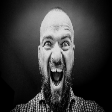

In [4]:
from PIL import Image
import numpy as np

def loadImage(filename):
    img = Image.open(filename).convert("L").resize( size=(112,112) )
    img_data = np.array(img).astype(np.float32)
    return torch.tensor(img_data)

def tensorToImage(tensor):
    return Image.fromarray(tensor.clamp(0,255).detach().reshape(112,112).numpy().astype(np.uint8))

Xoriginal = loadImage('angry.png')
print(Xoriginal)
tensorToImage(Xoriginal)

# 4. Modify the photo and see the new emotion

In [5]:
# TODO, example below
easy_first = loadImage("neutral.png")
easy_second = loadImage('neutral.png')
easy_second[85:87,40:70] = 255

medium_first = loadImage('angry.png')
medium_second = loadImage('angry.png')


hard_first = loadImage('happy.png')
hard_second = loadImage('happy.png')

The `compare_images` function will help you quickly view both images together with the model's predictions.

**IMPORTANT!!**

Before being passed to the model, images are rounded to the nearest integer pixel values. For example, if a pixel has value 225.3, it becomes 225.

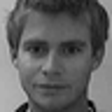

predictions A:
    98.6% - neutral
     0.3% - happy
     0.2% - surprise
     0.3% - sad
     0.2% - angry
     0.0% - disgust
     0.0% - fear
     0.4% - contempt
emotion A = neutral



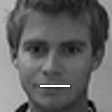

predictions B:
    30.8% - neutral
    65.7% - happy
     0.6% - surprise
     0.3% - sad
     0.4% - angry
     0.0% - disgust
     0.2% - fear
     2.1% - contempt
emotion B = happy

distance = 11851


In [6]:
def compare_images(A, B):
    predictionA = model(A.clamp(0,255).round()).squeeze().softmax(-1)
    predictionB = model(B.clamp(0,255).round()).squeeze().softmax(-1)

    display(tensorToImage(A))
    print("predictions A:")
    for emotion, probability in zip(emotion_labels, predictionA):
        print(f"{probability*100:8.1f}% - {emotion}")

    emotionA = emotion_labels[predictionA.argmax()]
    print(f"emotion A = {emotionA}\n")

    display(tensorToImage(B))
    print("predictions B:")
    for emotion, probability in zip(emotion_labels, predictionB):
        print(f"{probability*100:8.1f}% - {emotion}")

    emotionB = emotion_labels[predictionB.argmax()]
    print(f"emotion B = {emotionB}\n")

    distance = (A.round() - B.round()).abs().sum().int().item()
    print(f"distance = {distance}")


compare_images(easy_first, easy_second)

In [7]:
def optimal_attack(
    orig_img, target_class, away=False, pixels_per_step=5, max_steps=15000
):
    """
    Phase 1: Greedily step pixels by 1 unit with monotonicity to cross boundary.
    Phase 2: Intelligently trim pixels back towards the original values.
    """
    x = orig_img.clone().float()
    direction = torch.zeros(112 * 112, device=x.device)

    # Phase 1: Guided L1 Steepest Descent (Monotonicity prevents ping-ponging)
    for i in range(max_steps):
        # We must strictly check success on the ROUNDED image!
        with torch.no_grad():
            pred_rounded = model(x.round()).squeeze().argmax().item()
            success = (
                (pred_rounded == target_class)
                if not away
                else (pred_rounded != target_class)
            )
            if success:
                break

        x_var = x.clone().requires_grad_(True)
        out = model(x_var).squeeze()

        others = torch.cat([out[:target_class], out[target_class + 1 :]])
        if not away:
            loss = others.max() - out[target_class]
        else:
            loss = out[target_class] - others.max()

        loss.backward()

        with torch.no_grad():
            grad = x_var.grad.view(-1)
            x_flat = x.view(-1)

            # Prevent reverting any previously determined direction in Phase 1
            valid_mask = ((grad < 0) & (x_flat < 255) & (direction >= 0)) | (
                (grad > 0) & (x_flat > 0) & (direction <= 0)
            )

            abs_grad = grad.abs()
            abs_grad[~valid_mask] = -1

            top_idx = abs_grad.argsort(descending=True)[:pixels_per_step]

            if abs_grad[top_idx[0]] <= 0:
                if direction.abs().sum() > 0:
                    # Relax monotonicity constraints if we get stuck in a local minimum
                    direction.zero_()
                    continue
                else:
                    break

            for idx in top_idx:
                if abs_grad[idx] > 0:
                    sign = grad[idx].sign()
                    x_flat[idx] -= sign
                    direction[idx] = -sign

            x = x_flat.view(112, 112)

    best_img = x.round()

    # Phase 2: Gradient-Guided Perfect Trimming
    for trim_pass in range(25):
        diff = best_img - orig_img.round()
        indices = diff.nonzero(as_tuple=False)
        if len(indices) == 0:
            break

        x_var = best_img.clone().requires_grad_(True)
        out = model(x_var).squeeze()
        others = torch.cat([out[:target_class], out[target_class + 1 :]])
        if not away:
            loss = others.max() - out[target_class]
        else:
            loss = out[target_class] - others.max()
        loss.backward()
        grads = x_var.grad

        def score_revert(idx_list):
            r, c = idx_list[0], idx_list[1]
            orig_val = orig_img.round()[r, c].item()
            curr_val = best_img[r, c].item()
            step = 1 if orig_val > curr_val else -1
            # Sort order prioritizes reverts that increase the loss the absolute least
            return grads[r, c].item() * step

        sorted_indices = sorted(indices.tolist(), key=score_revert)
        changed_in_pass = False

        for r, c in sorted_indices:
            orig_val = orig_img.round()[r, c].item()
            curr_val = best_img[r, c].item()
            if curr_val == orig_val:
                continue

            step = 1 if orig_val > curr_val else -1
            test_img = best_img.clone()
            test_img[r, c] += step

            pred = model(test_img).squeeze().argmax().item()
            success = (pred == target_class) if not away else (pred != target_class)

            # If classification successfully holds, lock in the reverted change
            if success:
                best_img = test_img
                changed_in_pass = True

        if not changed_in_pass:
            break

    return best_img

In [8]:
HAPPY = emotion_labels.index("happy")

# Subtask 1

Generate two images: one not happy and one happy, with the smallest possible pixel distance

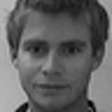

predictions A:
    40.8% - neutral
    40.6% - happy
     0.0% - surprise
     0.1% - sad
     0.0% - angry
     0.0% - disgust
     0.0% - fear
    18.4% - contempt
emotion A = neutral



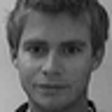

predictions B:
    40.8% - neutral
    40.8% - happy
     0.0% - surprise
     0.1% - sad
     0.0% - angry
     0.0% - disgust
     0.0% - fear
    18.2% - contempt
emotion B = happy

distance = 1


In [9]:
easy_orig = loadImage("neutral.png")
easy_second = optimal_attack(
    easy_orig, HAPPY, away=False, pixels_per_step=2, max_steps=5000
)

# Achieve EXACTLY L1 Distance = 1.
# easy_second has been stripped back precisely to the boundary.
# Take one 1-unit step backward to immediately flip it back.
easy_first = easy_second.clone()
diff = easy_second - easy_orig.round()
indices = diff.nonzero(as_tuple=False)

for idx in indices:
    r, c = idx[0], idx[1]
    orig_val = easy_orig.round()[r, c].item()
    curr_val = easy_second[r, c].item()

    if orig_val != curr_val:
        step = 1 if orig_val > curr_val else -1
        easy_first[r, c] += step

        # Verify it successfully broke out of the "Happy" classification constraint
        if model(easy_first).squeeze().argmax().item() != HAPPY:
            break
        easy_first[r, c] -= step

compare_images(easy_first, easy_second)

# Subtask 2

Add a single image (along angry.png) that is close to the given one and becomes happy

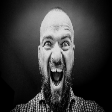

predictions A:
     0.0% - neutral
     0.1% - happy
     9.5% - surprise
    18.2% - sad
    72.0% - angry
     0.0% - disgust
     0.1% - fear
     0.0% - contempt
emotion A = angry



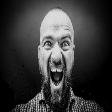

predictions B:
    16.0% - neutral
    22.7% - happy
    16.0% - surprise
    22.7% - sad
    22.7% - angry
     0.0% - disgust
     0.0% - fear
     0.0% - contempt
emotion B = happy

distance = 1865


In [10]:
medium_first = loadImage("angry.png")
# Using larger pixels_per_step to confidently cover the ~1900 L1 distance needed
medium_second = optimal_attack(
    medium_first, HAPPY, away=False, pixels_per_step=5, max_steps=15000
)

compare_images(medium_first, medium_second)

# Subtask 3

Add a single image (along happy.png) that is close to the given one and is not happy

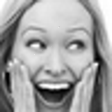

predictions A:
     0.1% - neutral
    41.2% - happy
    41.4% - surprise
     0.1% - sad
     5.2% - angry
     0.0% - disgust
    12.0% - fear
     0.0% - contempt
emotion A = surprise



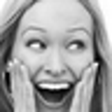

predictions B:
     0.1% - neutral
    58.1% - happy
    34.4% - surprise
     0.1% - sad
     2.8% - angry
     0.0% - disgust
     4.6% - fear
     0.0% - contempt
emotion B = happy

distance = 51


In [11]:
hard_second = loadImage("happy.png")
hard_first = optimal_attack(
    hard_second, HAPPY, away=True, pixels_per_step=2, max_steps=5000
)

compare_images(hard_first, hard_second)

# 5. Save Answers for submission to the site

In [ ]:
import json


def toList(tensor):
    return tensor.clamp(0, 255).round().int().tolist()


answers = {
    "easy": {"first": toList(easy_first), "second": toList(easy_second)},
    "medium": {
        "second": toList(medium_second),
    },
    "hard": {
        "first": toList(hard_first),
    },
}
with open("answers.json", "w") as f:
    json.dump(answers, f)
print("Answers precisely saved for submission.")